In [1]:
import pandas as pd
import networkx as nx
import numpy as np

data = 'data/gsv3/gsv3_entity_collaboration.csv'

In [2]:
# for visualization
from IPython.display import SVG 
from sknetwork.visualization import svg_graph 
from sknetwork.data import Bunch 
from sknetwork.ranking import PageRank 
from scipy.sparse import csr_matrix

def draw_graph(G, show_names=False, node_size=1, font_size=10, edge_width=0.5):

    adjacency = nx.to_scipy_sparse_array(G, nodelist=None, dtype=None, weight='weight', format='csr')
    adjacency = csr_matrix(adjacency) # fix to weird sknetwork-csr issue; comment out to troubleshoot
    
    names = np.array(list(G.nodes))
    
    graph = Bunch()
    graph.adjacency = adjacency
    graph.names = np.array(names)
    
    pagerank = PageRank()
    scores = pagerank.fit_transform(adjacency)

    if show_names:
        
        image = svg_graph(graph.adjacency, font_size=font_size, node_size=node_size, names=graph.names, width=700, height=500, scores=scores, edge_width=edge_width)
    
    else:
        
        image = svg_graph(graph.adjacency, node_size=node_size, width=700, height=500, scores = scores, edge_width=edge_width)
    
    return SVG(image)

In [3]:
df = pd.read_csv(data)
df.head()

,source,target,date
0,Tipsy Scoop,Tipsy Scoop Queens,2023-10-08
1,Tipsy Scoop,Tipsy Scoop Queens,2024-01-25
2,Tipsy Scoop,Tipsy Scoop Queens,2026-01-14
3,Nico,David Bowie,2023-01-03
4,Nico,David Bowie,2025-12-01


In [4]:
df.shape

(338781, 3)

In [5]:
G = nx.from_pandas_edgelist(df)

In [6]:
print(G)

Graph with 29088 nodes and 150722 edges


# Degree Centrality
This is an indicators of importance, but they are really more of an indication of popularity. Often the lesser known nodes may be what you are actually looking for.

Today, nodes with high values will be popular, active, or influential.

Nodes with lower values will be less popular, active, or influential, as this algorithm has to do with the number of degrees, or the number of links.

Don't take centralities as synonyms for importance. They are simply measures that you can use, for understanding.

This shows a weakness of any search engines that prioritize popularity over relevance. Graphs can show pupularity. NLP can help identify relevancy. Graph and NLP together can be especially informative and powerful.

UPDATE: For day 69, we are using Degree Centrality instead of PageRank

In [7]:
# pagerank - Google founder's algorithm; we used this on day 68; leaving it here as an artifact, for easy reference 

score_df = pd.DataFrame([nx.pagerank(G)]).T
score_df.columns = ['score']
score_df.sort_values('score', ascending=False, inplace=True)
score_df

,score
Night Club 101,0.001280
Tractor,0.001058
Brooklyn Comedy Collective,0.001032
DeRay Davis,0.000984
Belly Up,0.000982
...,...
Cat's Cradle,0.000006
Regent Theatre - CA,0.000006
Neurolux Lounge,0.000006
Hello Houston,0.000006


In [8]:
# simpler algorithm to use this time - we care more about total number of degrees, not betweenness metrics
score_df = pd.DataFrame([nx.degree_centrality(G)]).T
score_df.columns = ['score']
score_df.sort_values('score', ascending=False, inplace=True)
score_df

,score
Brooklyn Comedy Collective,0.012342
Music Box,0.011070
Belly Up,0.010555
Hollywood Improv,0.010314
Old Mervs,0.009317
...,...
Ypsi Fine Arts Club: Riverside Arts Center,0.000034
Lea Salonga Concert,0.000034
Winter Art Market: York Food & Drink,0.000034
Dear 2026,0.000034


In [9]:
# the labels I want to use
labels_wanted = ['D', 'C', 'B', 'A', 'S']

# count of labels wanted
desired_q = len(labels_wanted)

score_df['class'] = pd.qcut(score_df['score'], q=desired_q, duplicates='drop')

# get the actual number of bins created; in case less than q
n_bins = score_df['class'].nunique()

# add the labels
score_df['class'] = pd.qcut(score_df['score'], q=desired_q, labels=labels_wanted, duplicates='drop')

score_df['class'].value_counts().sort_index()

class
D    8711
C    3344
B    6300
A    5005
S    5728
Name: count, dtype: int64

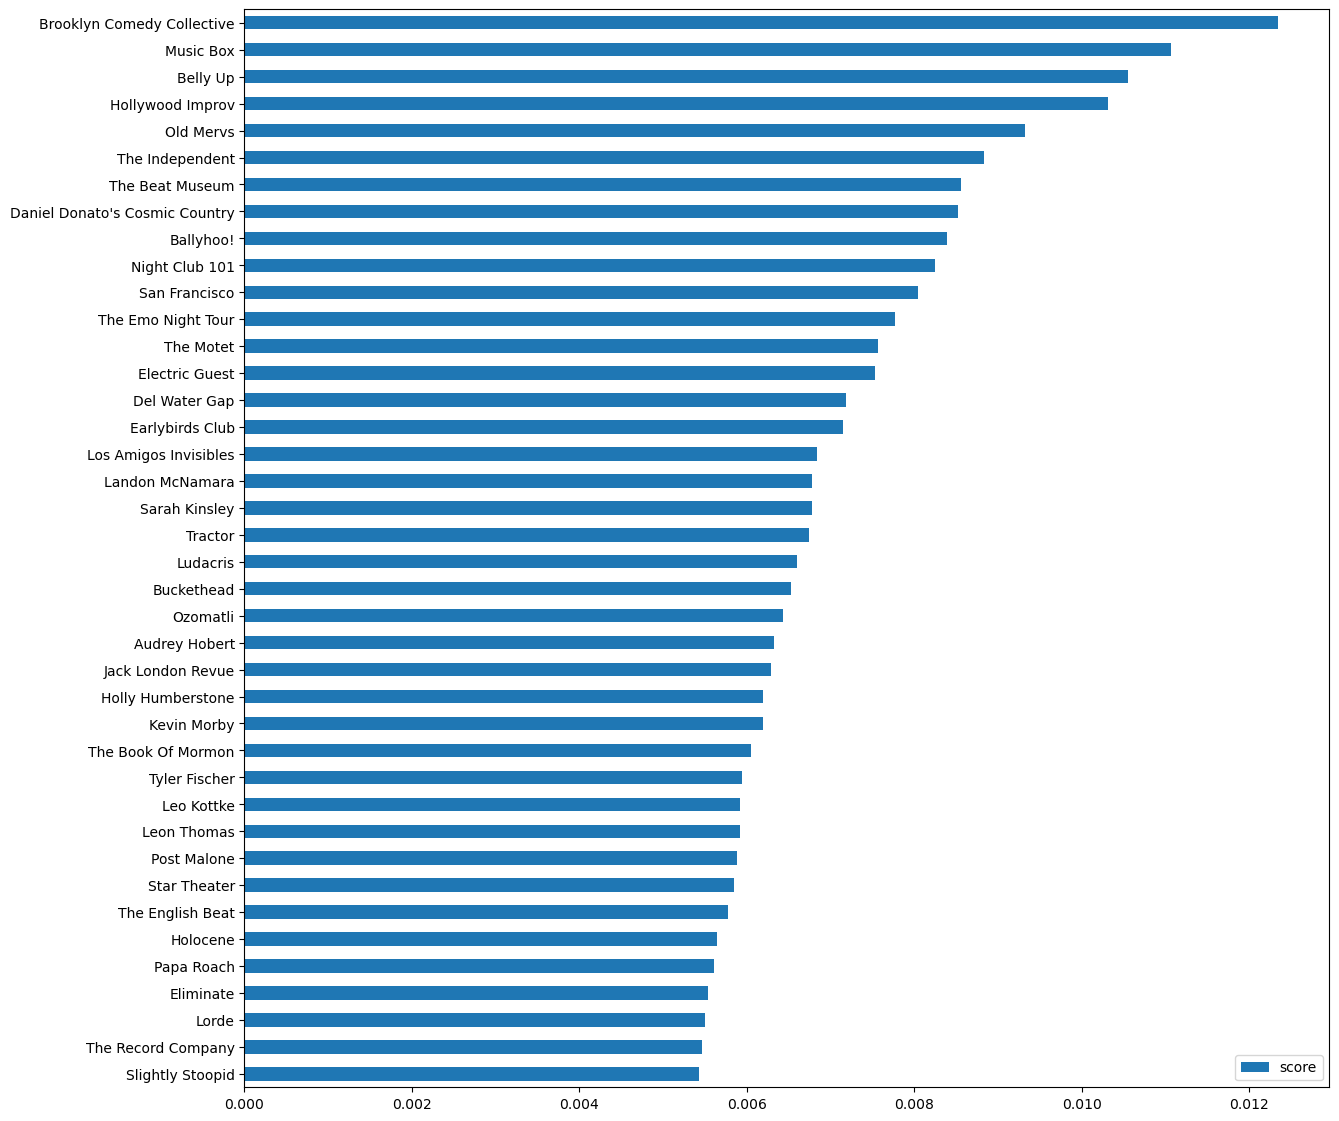

In [10]:
check_df = score_df[score_df['class']=='S']
check_df.head(40).plot.barh(figsize=(14, 14)).invert_yaxis()

In [11]:
def preview_class_ego_networks(search_class='S'):

    check_df = score_df[score_df['class']==search_class] # LOAD CLASS NODES

    entity = check_df.sample(1).index.values[0] # LOAD A RANDOM NODE

    ego = nx.ego_graph(G, entity) # CAPTURE ITS EGO GRAPH

    related_entities = sorted(ego.nodes) # SEE THE NODES AS TEXT

    related_entities = [e for e in related_entities if e is not entity]

    print('Entity: {}'.format(entity))
    print()
    print('Related Entities:')
    
    print(', '.join(related_entities))

#     for related_entity in related_entities:
#         print('- {}'.format(related_entity))

    #nx.draw_spring(ego, with_labels=True, node_size=200, width=0.2, font_size=8) # DRAW IT

    return draw_graph(ego, node_size=10, edge_width=0.5, show_names=True, font_size=12)

Entity: Peach Pit

Related Entities:
Artikal Sound System, Bad Suns, Ben Harper & The Innocent Criminals, Big Boi, Bill Graham Civic Auditorium, Blink-182, Bowling for Soup, Briston Maroney, Buena Vista Orchestra, Børns, Cage The Elephant, Catie Turner, Chris Pierce, Common People, Daniel Bonte, Dashboard Confessional, Deer Tick, Dogpark, Duran Duran, Easy Honey, Eve 6, Fitz and The Tantrums, Flipturn, Fortunate Youth, Frankenreiter, Goo Goo Dolls, Grouplove, Hendrix, James Taylor and His All-Star Band, Jason DeVore, Jen Pop, Jeremy Buck, Joan Jett & The Blackhearts, Landon McNamara, Lindberg, Lord Huron, Makua Jim, Makua Jim Lindberg, Makua Jim Lindberg (Pennywise), Mike Watt, Mumford & Sons, My Morning Jacket, Myles Smith, OK Go, PawnShop Kings, Pennywise, Poolside, Public Enemy, Righteous Waves, Sheryl Crow, Silversun Pickups, Slightly Stoopid, Sublime, Sugar Ray, Surfer Girl, Switchfoot, Taft Buckley, The Backfires, The Bombpops, The Chainsmokers, The Fray, The Offspring, The Only 

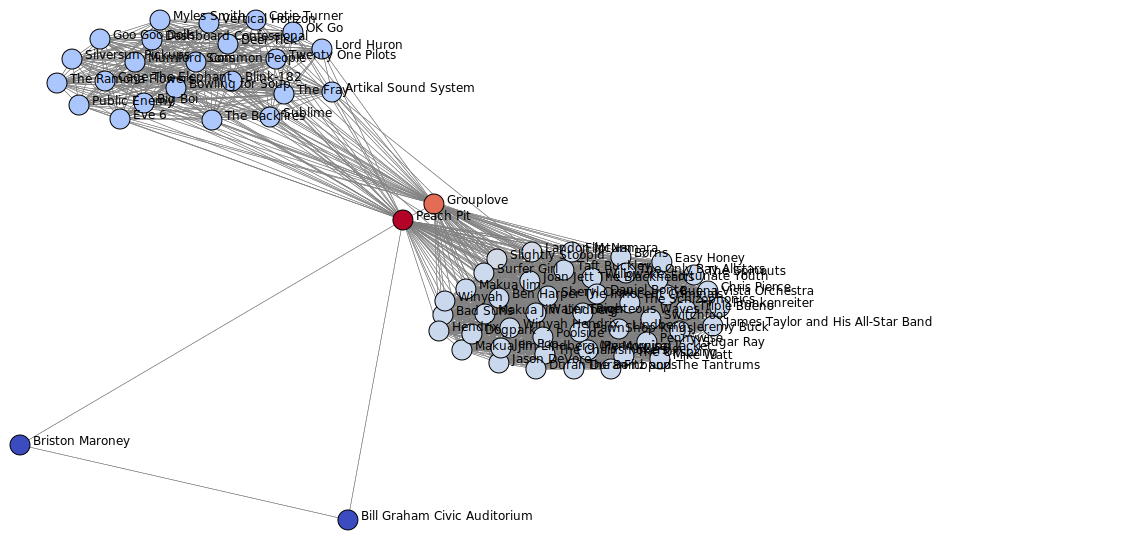

In [35]:
preview_class_ego_networks('S') # S, A, B, C, or D

# Class Ecosystems

In [13]:
# # don't bother! use cosmograph! export from check_df,if you want to!
# this is very cool, but don't want to demo it right now. challenge yourself!

# check_df = score_df[score_df['class']=='S']
# class_nodes = sorted(check_df.index.values)

# G_sub = G.subgraph(class_nodes)

# #nx.draw_spring(G_sub, with_labels=True, node_size=200, width=0.2, font_size=8)
# draw_graph(G_sub, node_size=1, edge_width=0.1)